In [1]:
# IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import os

# LOAD DATASET
df = pd.read_csv("messy_ecommerce_sales_data.csv")

# CREATE FOLDER FOR CHARTS
os.makedirs("images", exist_ok=True)

In [2]:
# -------------------------------
# 🧹 DATA CLEANING

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Check dataset
print(df.head())
print(df.info())

# Handle missing values
df = df.drop_duplicates()

# Fill or drop missing values
df = df.dropna(subset=['price', 'quantity'])

# Convert data types
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')

# Create total sales column
df['total_spent'] = df['price'] * df['quantity']

# Convert date column (adjust name if needed)
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Drop rows with invalid dates
df = df.dropna(subset=['order_date'])


    id customer_name   order_id  order_date        product     category  \
0  100  Customer_100  ORD-41285  11/22/2024        Blender         Home   
1  101  Customer_101  ORD-35783    7/5/2025     Smartphone  Electronics   
2  102  Customer_102  ORD-84355  12/23/2024  Tennis Racket       Sports   
3  103  Customer_103  ORD-57811   3/19/2025        Science        Books   
4  104  Customer_104  ORD-93614  10/20/2025      Biography        Books   

  quantity   price    payment_method      status    total  
0        3      38  Cash on Delivery     Shipped   114.00  
1        2     abd            PayPal  Processing      NaN  
2        1  389.05            PayPal   Delivered   389.05  
3        5  233.92            PayPal  Processing  1169.60  
4        1  552.51  Cash on Delivery  Processing   552.51  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  --

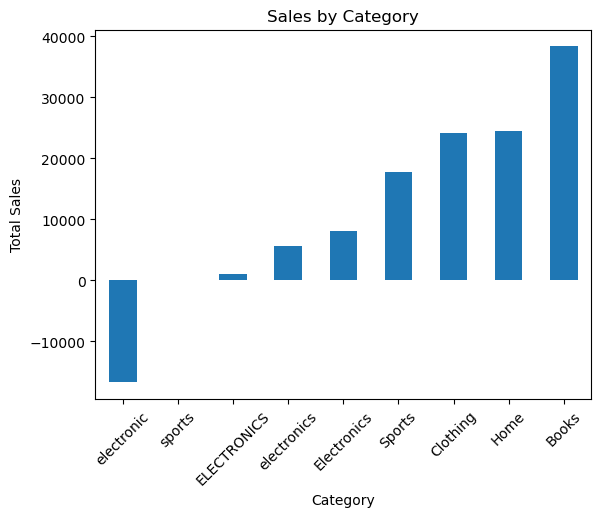

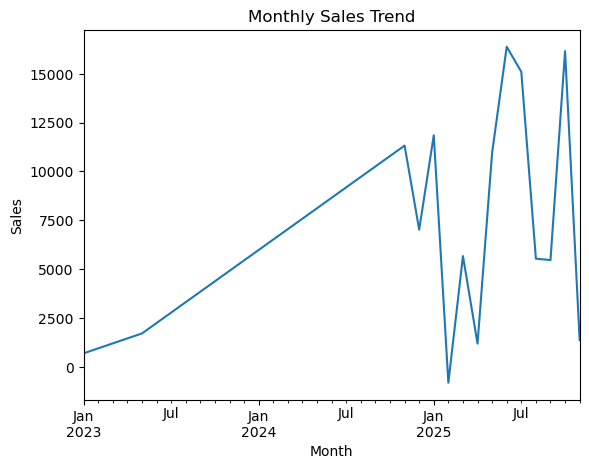

In [13]:
# 📊 DATA ANALYSIS

# 1. Sales by Category
category_sales = df.groupby('category')['total_spent'].sum().sort_values()

plt.figure()
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.savefig("images/sales_by_category.png", dpi=300, bbox_inches='tight')
plt.show()


# 2. Monthly Sales Trend
df['month'] = df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('month')['total_spent'].sum()

plt.figure()
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.savefig("images/monthly_sales_trend.png", dpi=300, bbox_inches='tight')
plt.show()


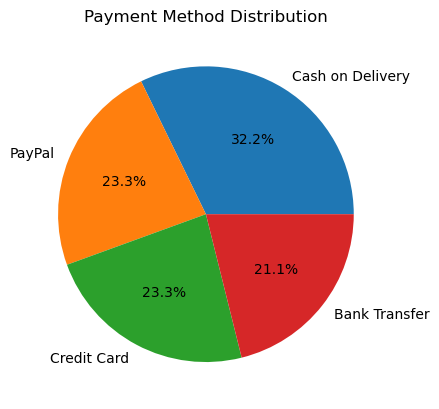

In [4]:
# 3. Payment Method Distribution
payment_counts = df['payment_method'].value_counts()

plt.figure()
payment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.ylabel("")

plt.savefig("images/payment_method_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


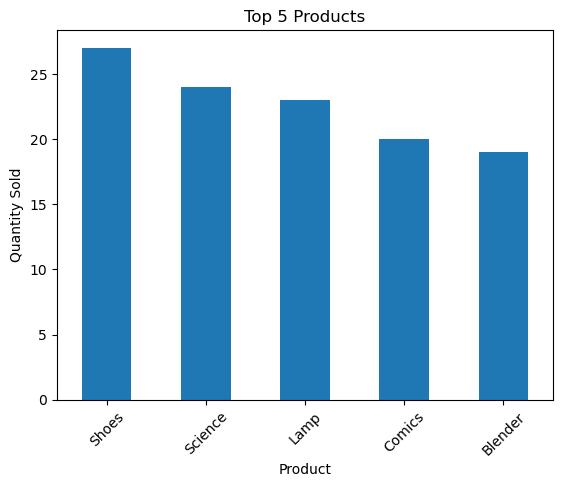

In [11]:
# 4. Top 5 Products
top_products = df.groupby('product')['quantity'].sum().sort_values(ascending=False).head(5)

plt.figure()
top_products.plot(kind='bar')
plt.title("Top 5 Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)

plt.savefig("images/top_products.png", dpi=300, bbox_inches='tight')
plt.show()

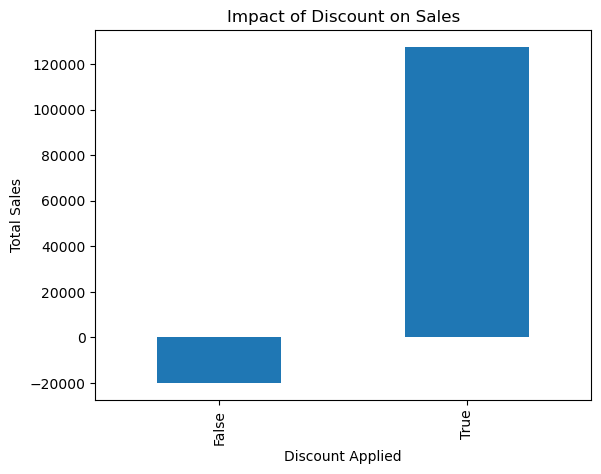

In [17]:
# 5. Discount Impact

# Create discount column
df['discount_applied'] = df['price'] < 1000

# Analysis
discount_sales = df.groupby('discount_applied')['total'].sum()

plt.figure()
discount_sales.plot(kind='bar')
plt.title("Impact of Discount on Sales")
plt.xlabel("Discount Applied")
plt.ylabel("Total Sales")

plt.savefig("images/discount_impact.png", dpi=300, bbox_inches='tight')
plt.show()



In [21]:
# SAVE CLEAN DATA (VERY IMPORTANT FOR CLIENTS)
df.to_csv("cleaned_ecommerce_data.csv", index=False)

print("✅ Project Completed Successfully")

✅ Project Completed Successfully
